In [17]:
import re
from glob import glob
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import os
from glob import glob
from matplotlib.patches import Rectangle

sys.path.insert(0, "/scratch/elena/9Li/scripts")

import geometry_wcte
import functions_multilateration

# -----------------------------------------
# Plot style
# -----------------------------------------

rcParams["mathtext.fontset"] = "stix"
rcParams["font.family"] = "STIXGeneral"

rcParams["figure.figsize"] = [16, 6]

rcParams["font.size"] = 22
rcParams["axes.labelsize"] = 20
rcParams["axes.titlesize"] = 20
rcParams["legend.fontsize"] = 16
rcParams["xtick.labelsize"] = 12
rcParams["ytick.labelsize"] = 16


# ==============================================================================
# Choose run
# ==============================================================================

run_number = 1848
processed_folder = f"/scratch/elena/9Li/results/run{run_number}/processed"

print(f"Run {run_number}")
print(f"Folder: {processed_folder}")

# ==============================================================================
# Read all pickle files
# ==============================================================================

all_files = sorted(glob(f"{processed_folder}/*.pkl"))

# ==============================================================================
# Helper function
# ==============================================================================

def load_dataframe(file_list, label):

    if len(file_list) == 0:
        print(f"{label:<15}:   0 files")
        return pd.DataFrame()

    df = pd.concat(
        [pd.read_pickle(f) for f in file_list],
        ignore_index=True
    )

    print(f"{label:<15}: {len(file_list):2d} files   ({len(df):8,d} clusters)")

    return df


# ==============================================================================
# STAGE 1
# Sliding windows
# ==============================================================================

stage1_sig_files = sorted([
    f for f in all_files
    if "Li9_clusters_chunk_" in f
    and "_multilat" not in f
    and "Refine_" not in f
    and "Final_FV_" not in f
    and "_BKG" not in f
])

stage1_bkg_files = sorted([
    f for f in all_files
    if "Li9_clusters_chunk_" in f
    and "_multilat" not in f
    and "Refine_" not in f
    and "Final_FV_" not in f
    and "_BKG" in f
])


# ==============================================================================
# STAGE 2
# Multilateration
# ==============================================================================

stage2_sig_files = sorted([
    f for f in all_files
    if "_multilat.pkl" in f
    and "_BKG" not in f
])

stage2_bkg_files = sorted([
    f for f in all_files
    if "_BKG_multilat.pkl" in f
])


# ==============================================================================
# STAGE 4
# Refinement
# ==============================================================================

stage4_sig_files = sorted([
    f for f in all_files
    if "Refine_Li9_clusters" in f
    and "_BKG" not in f
])

stage4_bkg_files = sorted([
    f for f in all_files
    if "Refine_Li9_clusters" in f
    and "_BKG" in f
])


# ==============================================================================
# STAGE 5
# Final FV
# ==============================================================================

stage5_sig_files = sorted([
    f for f in all_files
    if "Final_FV_" in f
    and "_BKG" not in f
])

stage5_bkg_files = sorted([
    f for f in all_files
    if "Final_FV_" in f
    and "_BKG" in f
])


# ==============================================================================
# Load all DataFrames
# ==============================================================================

df_stage1_sig = load_dataframe(stage1_sig_files, "Stage 1 SIG")
df_stage1_bkg = load_dataframe(stage1_bkg_files, "Stage 1 BKG")

df_stage2_sig = load_dataframe(stage2_sig_files, "Stage 2 SIG")
df_stage2_bkg = load_dataframe(stage2_bkg_files, "Stage 2 BKG")

df_stage4_sig = load_dataframe(stage4_sig_files, "Stage 4 SIG")
df_stage4_bkg = load_dataframe(stage4_bkg_files, "Stage 4 BKG")

df_stage5_sig = load_dataframe(stage5_sig_files, "Stage 5 SIG")
df_stage5_bkg = load_dataframe(stage5_bkg_files, "Stage 5 BKG")

print(f"\nAll DataFrames loaded successfully for run{run_number}")

Run 1848
Folder: /scratch/elena/9Li/results/run1848/processed
Stage 1 SIG    : 31 files   ( 171,656 clusters)
Stage 1 BKG    : 16 files   (  84,406 clusters)
Stage 2 SIG    : 31 files   ( 171,656 clusters)
Stage 2 BKG    : 16 files   (  84,406 clusters)
Stage 4 SIG    : 31 files   (  50,955 clusters)
Stage 4 BKG    : 16 files   (  25,284 clusters)
Stage 5 SIG    :  1 files   (     597 clusters)
Stage 5 BKG    :  1 files   (     287 clusters)

All DataFrames loaded successfully for run1848


In [18]:
df_stage5_sig.columns

Index(['t_window_start_ns', 't_window_start_rel_ns', 'nHits', 't_rms_ns',
       'spill_id', 'nCLusters_in_spill', 'hit_slot_ids', 'hit_position_ids',
       'hit_times_ns', 'hit_charges', 'vertex_x', 'vertex_y', 'vertex_z',
       'fit_success', 'n_hits_used', 'time_rms', 'chi2', 'ndof', 'chi2_ndof',
       'v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine'],
      dtype='object')

In [19]:
df_stage5_sig[["vertex_x","vertex_y","vertex_z"]].describe()

,vertex_x,vertex_y,vertex_z
count,597.000000,597.000000,597.000000
mean,-2.129636,6.734409,-65.561196
std,26.048323,46.429589,78.161157
min,-192.797432,-204.512879,-300.000000
25%,-11.110323,-12.023276,-118.162117
50%,-1.179171,-1.233976,-82.292041
75%,10.757694,10.840944,-31.376603
max,124.495887,264.613511,300.000000


In [76]:
def plot_vertex_maps(df_sig, df_bkg, stage_name):

    if {"v_x_fine", "v_y_fine", "v_z_fine"}.issubset(df_sig.columns):

        xcol = "v_x_fine"
        ycol = "v_y_fine"
        zcol = "v_z_fine"

    else:

        xcol = "vertex_x"
        ycol = "vertex_y"
        zcol = "vertex_z"


    beam_pipe = [0.0, 0.0, -138.7963]
    beam_halfwidth = 2.0      # cm  -> beam window = 4 cm diameter

    bins = 40
    vmax = 80

    # ---------------------------------------------------------
    # Same colour scale for ALL six histograms
    # ---------------------------------------------------------

    vmax_global = 0
    R = 153.7963
    H = 271.4235

    for df in (df_sig, df_bkg):

        mask = (
            df.fit_success
            & (df.chi2_ndof < 5)
            & (df[xcol]**2 + df[zcol]**2 <= R**2)
            & (np.abs(df[ycol]) <= H/2)
        )

        d = df.loc[mask]

        for x, y in [
            (d[xcol], d[ycol]),
            (d[zcol], d[xcol]),
            (d[zcol], d[ycol]),
        ]:
            hist2d, _, _ = np.histogram2d(x, y, bins=bins)
            vmax_global = max(vmax_global, hist2d.max())

    fig, axs = plt.subplots(2, 3, figsize=(24,14))

    datasets = [
        ("Signal", df_sig),
        ("Background", df_bkg)
    ]

    for row, (label, df) in enumerate(datasets):

        mask = (
            df.fit_success
            & (df.chi2_ndof < 5)
            & (df[xcol]**2 + df[zcol]**2 <= R**2)
            & (np.abs(df[ycol]) <= H/2))

        df_clean = df.loc[mask]

        print(f"{stage_name} - {label}: {len(df_clean)} clusters")

        # =====================================================
        # XY
        # =====================================================

        im = axs[row,0].hist2d(
            df_clean[xcol],
            df_clean[ycol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax
        )
      
        axs[row,0].set_xlim(-R-30, R+30)
        axs[row,0].set_ylim(-H/2-30, H/2+30)
        axs[row,0].set_aspect("auto")


        axs[row,0].add_patch(
            Rectangle(
                (beam_pipe[0]-beam_halfwidth,
                 beam_pipe[1]-beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2
            )
        )

        axs[row,0].set_title(f"{label} - XY plane")
        axs[row,0].set_xlabel("X [cm]")
        axs[row,0].set_ylabel("Y [cm]")

        plt.colorbar(im[3], ax=axs[row,0], label="Counts")

        # =====================================================
        # ZX
        # =====================================================

        im = axs[row,1].hist2d(
            df_clean[zcol],
            df_clean[xcol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax
        )

        axs[row,1].set_xlim(-R-30, R+30)
        axs[row,1].set_ylim(-R-30, R+30)
        axs[row,1].set_aspect("equal")

        axs[row,1].add_patch(
            Rectangle(
                (beam_pipe[2]-beam_halfwidth,
                 beam_pipe[0]-beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2
            )
        )

        axs[row,1].set_title(f"{label} - ZX plane")
        axs[row,1].set_xlabel("Z [cm]")
        axs[row,1].set_ylabel("X [cm]")

        plt.colorbar(im[3], ax=axs[row,1], label="Counts")

        # =====================================================
        # ZY
        # =====================================================

        im = axs[row,2].hist2d(
            df_clean[zcol],
            df_clean[ycol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax
        )
      
        axs[row,2].set_xlim(-R-30, R+30)
        axs[row,2].set_ylim(-H/2-30, H/2+30)
        axs[row,2].set_aspect("auto")

        axs[row,2].add_patch(
            Rectangle(
                (beam_pipe[2]-beam_halfwidth,
                 beam_pipe[1]-beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2
            )
        )

        axs[row,2].set_title(f"{label} - ZY plane")
        axs[row,2].set_xlabel("Z [cm]")
        axs[row,2].set_ylabel("Y [cm]")

        plt.colorbar(im[3], ax=axs[row,2], label="Counts")

    plt.suptitle(f"Run {run_number} - {stage_name}", fontsize=24)

    plt.tight_layout()

    plt.show()

Stage 2: Multilateration - Signal: 12980 clusters
Stage 2: Multilateration - Background: 6384 clusters


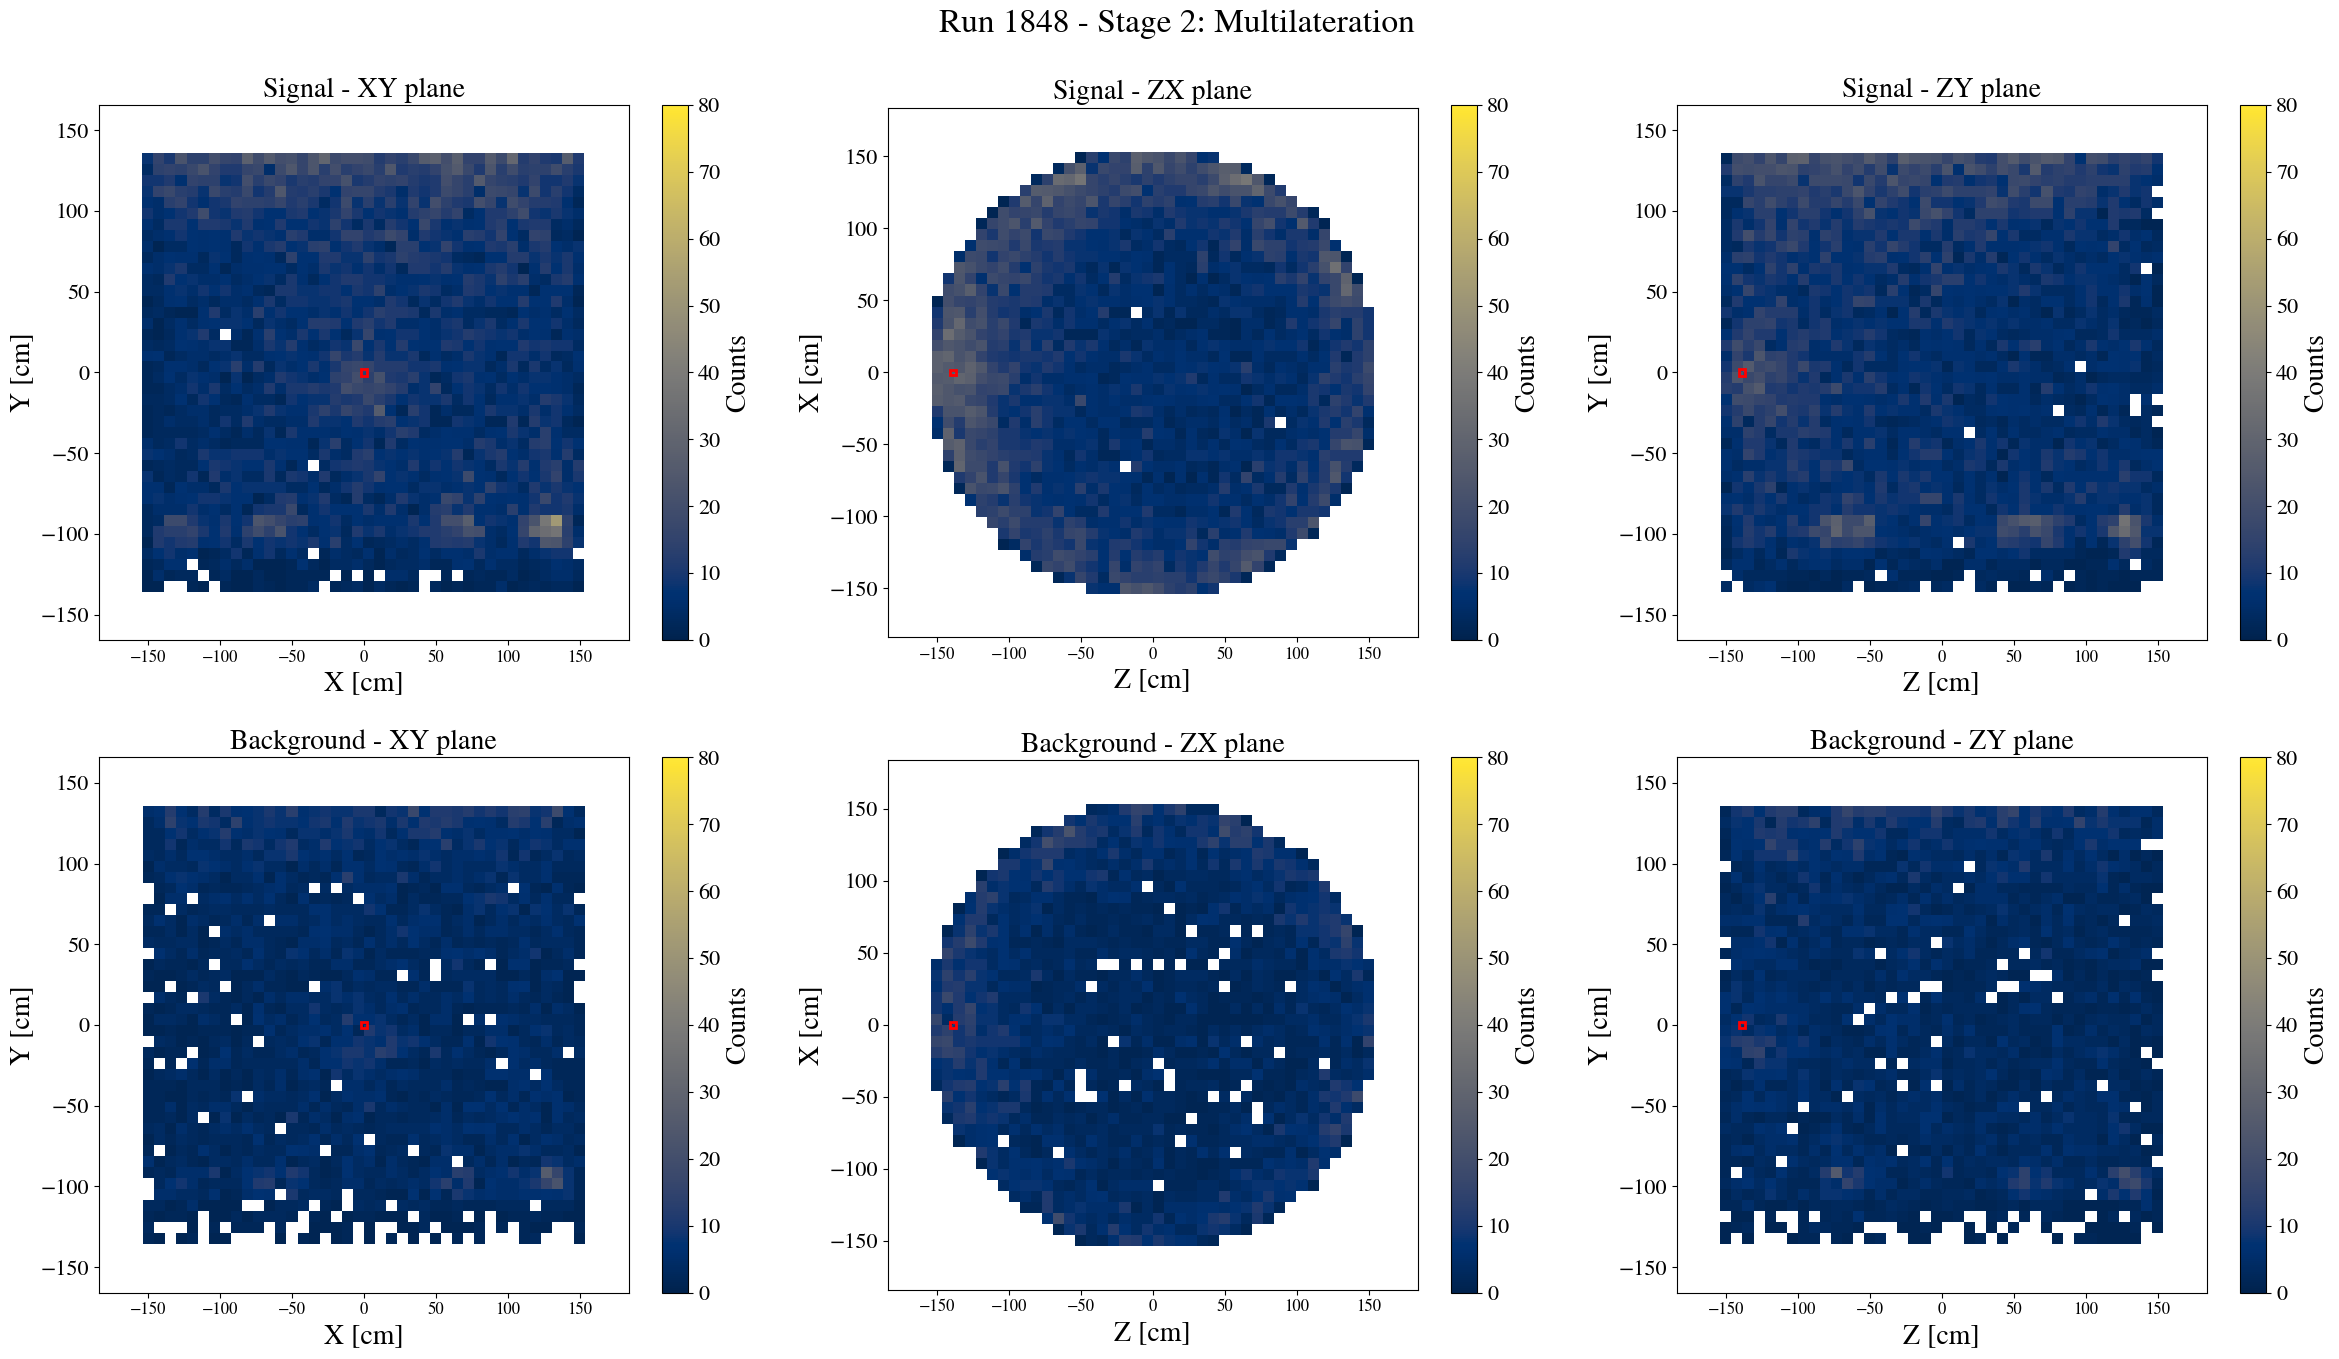

Stage 3: Refinement - Signal: 12636 clusters
Stage 3: Refinement - Background: 6187 clusters


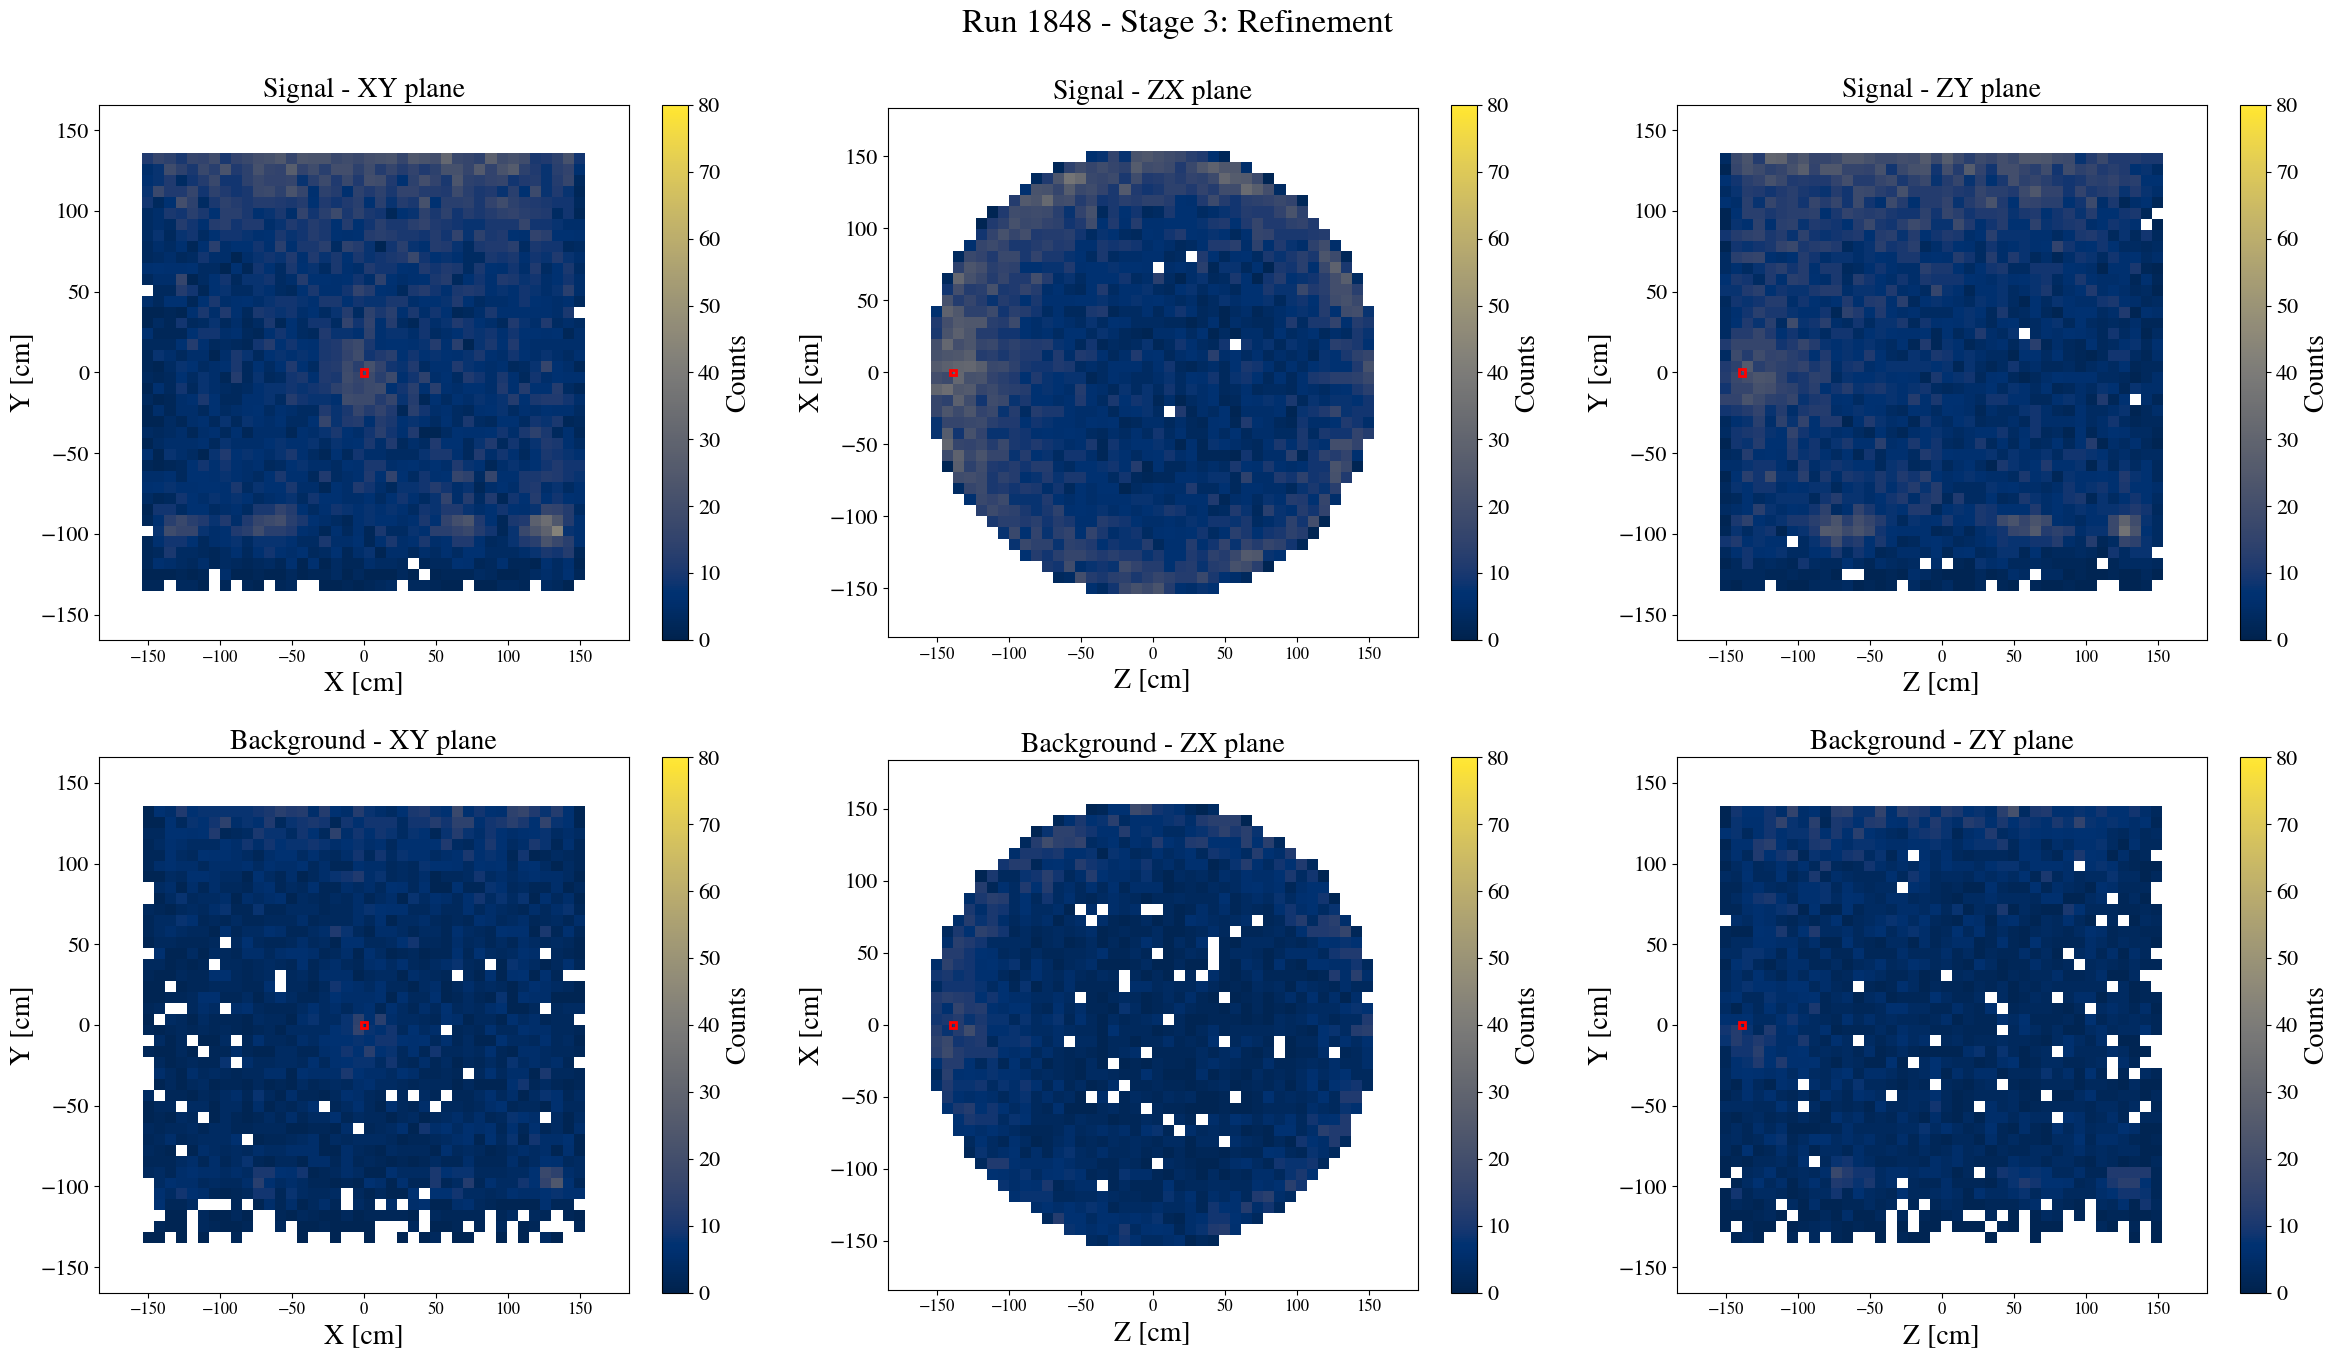

Stage 4: Final FV - Signal: 286 clusters
Stage 4: Final FV - Background: 142 clusters


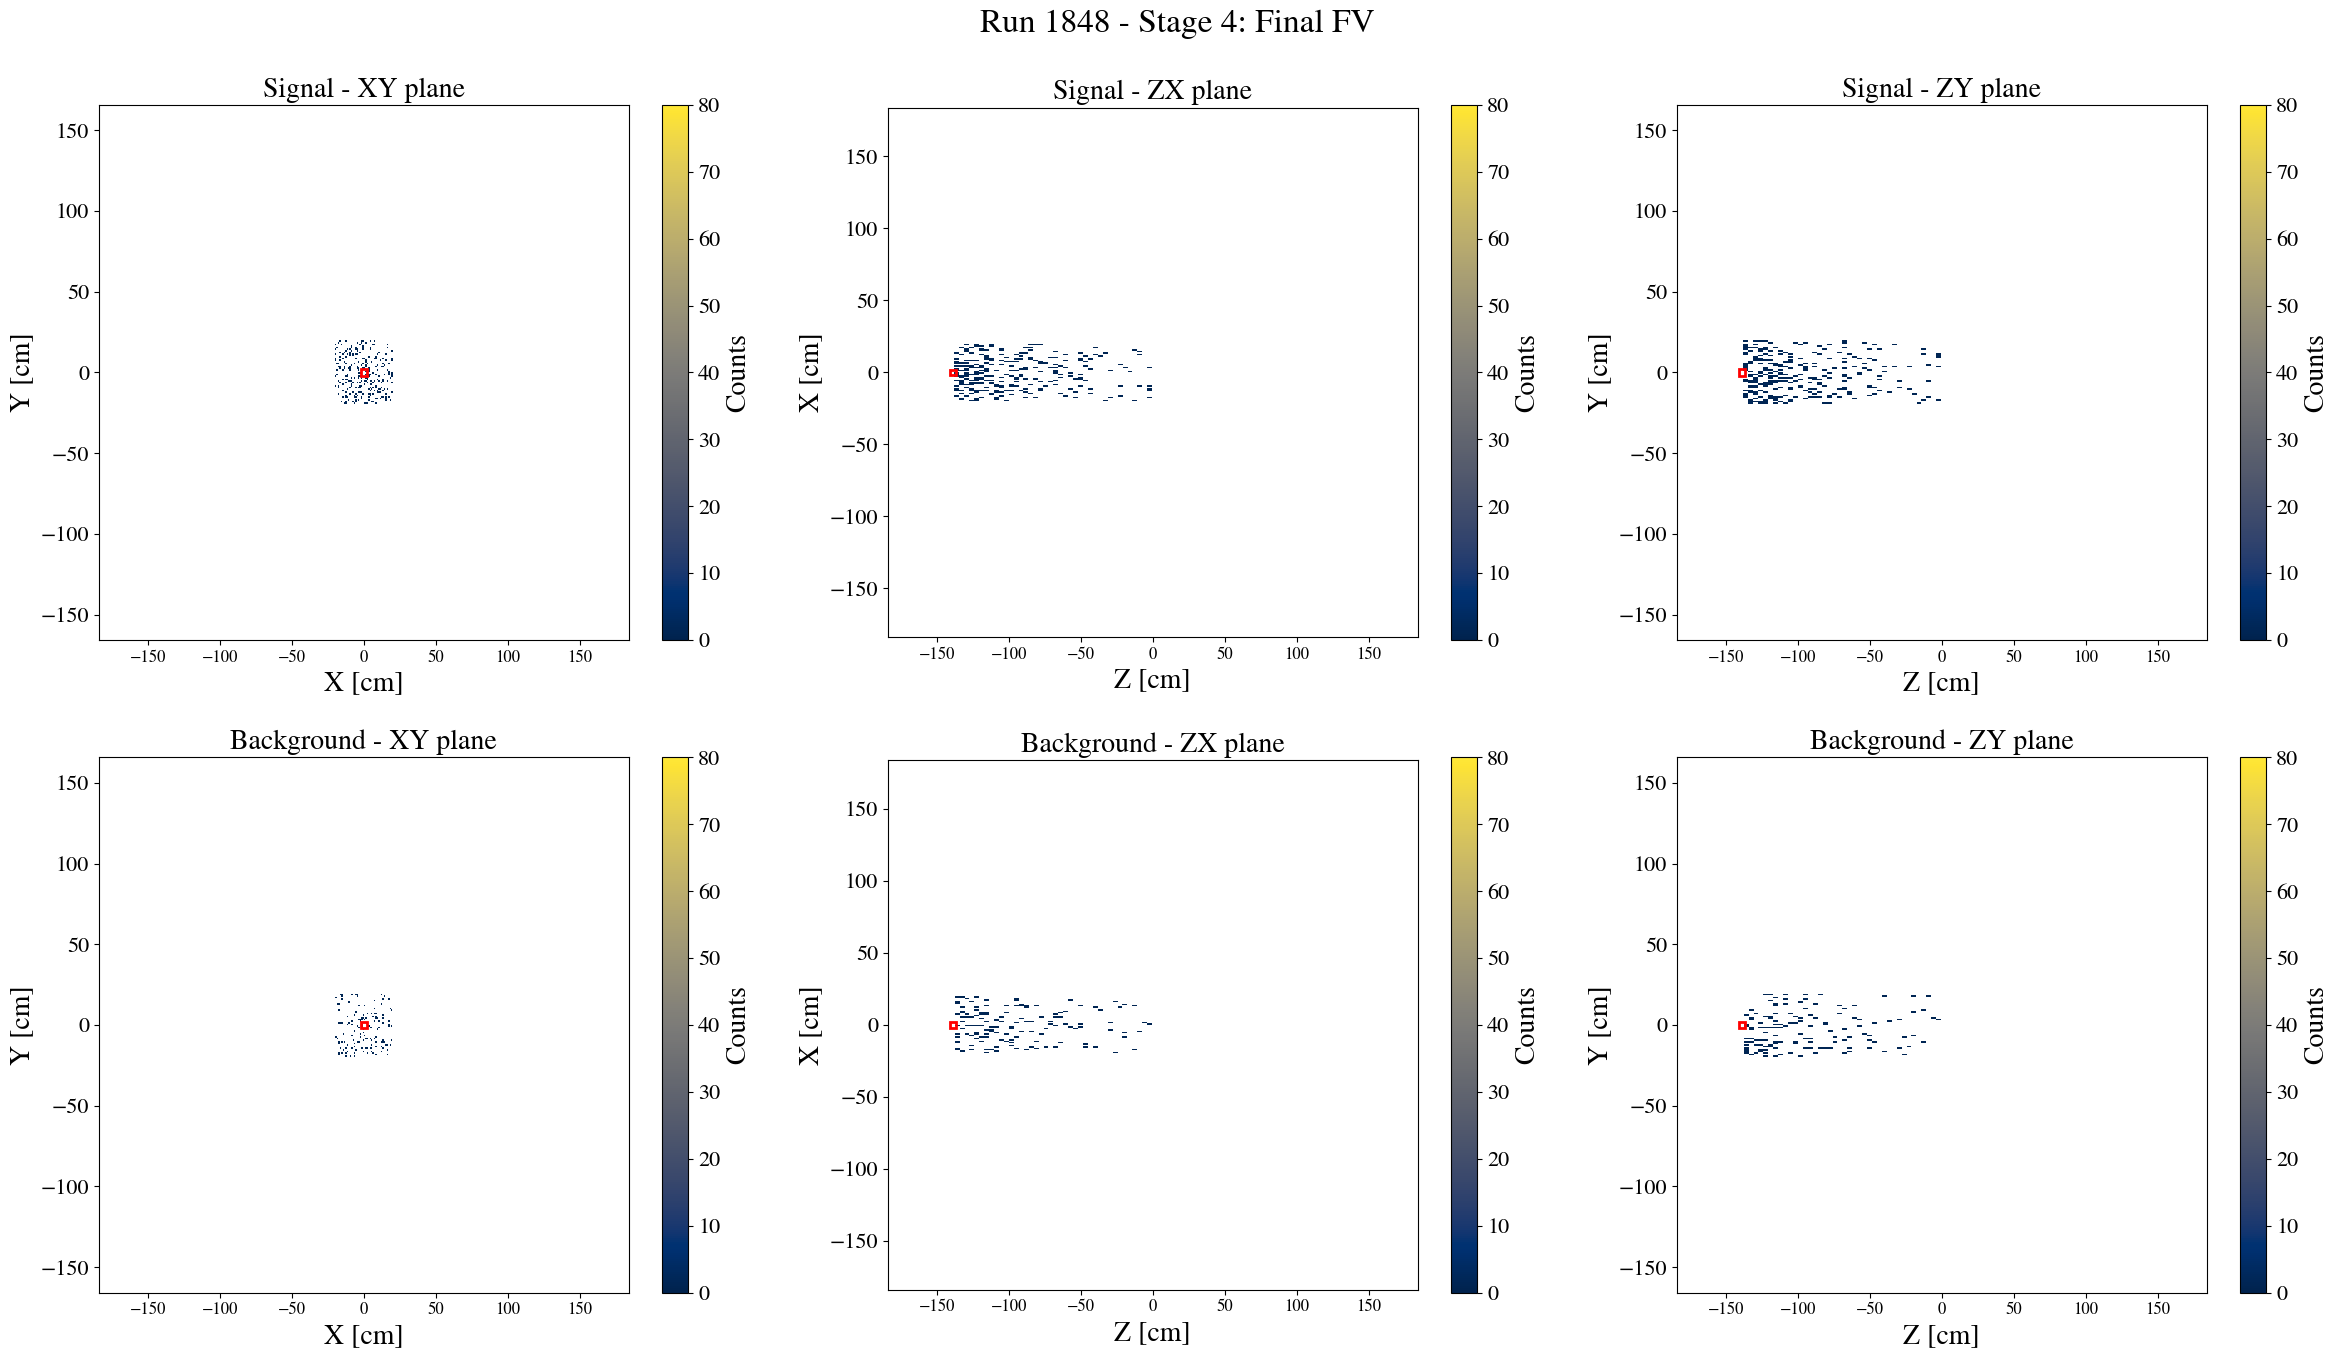

In [78]:
plot_vertex_maps(df_stage2_sig,df_stage2_bkg,"Stage 2: Multilateration")
plot_vertex_maps(df_stage4_sig,df_stage4_bkg,"Stage 3: Refinement")
plot_vertex_maps(df_stage5_sig,df_stage5_bkg,"Stage 4: Final FV")

##### check that the refinement vertex coordinates (v_x_fine) are different from the ones of the 1st iteration of the vertex reconstruction with the Multilaterator and the new geometry (WCTE convention)

In [82]:
print((df_stage4_sig["vertex_x"] == df_stage4_sig["v_x_fine"]).all())
print((df_stage4_sig["vertex_y"] == df_stage4_sig["v_y_fine"]).all())
print((df_stage4_sig["vertex_z"] == df_stage4_sig["v_z_fine"]).all())

False
False
False


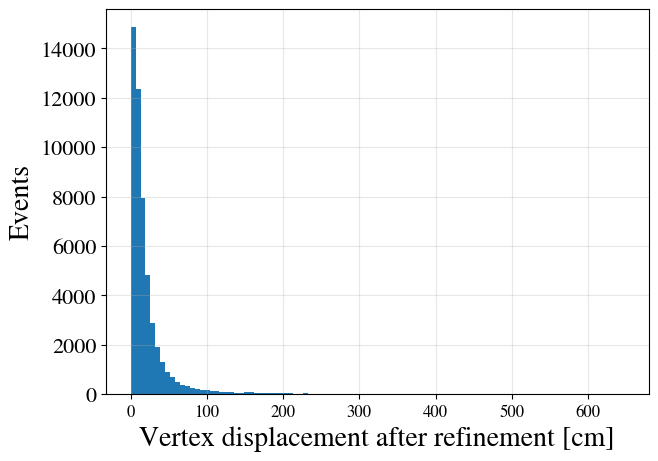

In [83]:
plt.figure(figsize=(7,5))

plt.hist(dr, bins=100)

plt.xlabel("Vertex displacement after refinement [cm]")
plt.ylabel("Events")

plt.grid(alpha=0.3)

Text(0, 0.5, 'Refined z [cm]')

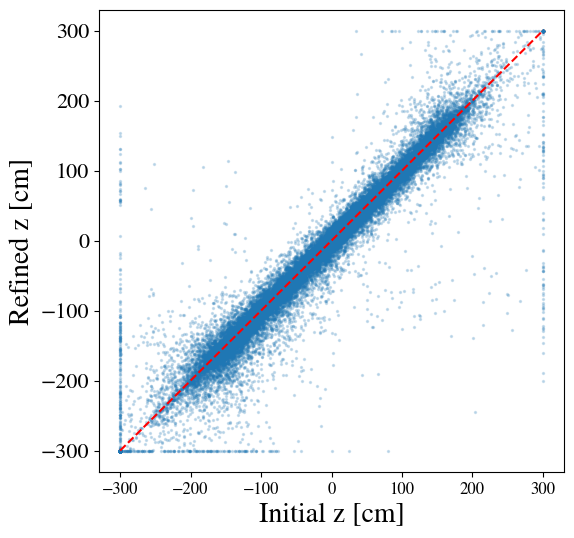

In [88]:
plt.figure(figsize=(6,6))

plt.scatter(df_stage4_sig["vertex_z"],df_stage4_sig["v_z_fine"],s=2,alpha=0.2)
plt.plot([-300,300],[-300,300],"r--")

plt.xlabel("Initial z [cm]")
plt.ylabel("Refined z [cm]")

### pasamos a los global plots (por beam momenta)

In [89]:
runs = [1846, 1848, 1928, 1930, 1932, 1934, 1935, 1936, 1937, 1938, 1939, 1941]

base_dir = "/scratch/elena/9Li/results"


def get_beam_momentum(run_id):
    if run_id in [1846, 1848]:
        return "-340 MeV/c"
    else:
        return "-260 MeV/c"


# dictionary storing the summary for both samples
summaries = {
    "signal": {"before": [], "after": []},
    "background (bkg)": {"before": [], "after": []},
}


for run in runs:

    run_folder = f"{base_dir}/run{run}/processed"
    momentum = get_beam_momentum(run)

    # --------------------------------------------------------------------------
    # process both signal and background samples
    # --------------------------------------------------------------------------

    for mode in ["signal", "background (bkg)"]:

        is_bkg = (mode == "background (bkg)")

        suffix = "_BKG" if is_bkg else ""

        refine_pattern = os.path.join(
            run_folder,
            f"Refine_Li9_clusters_chunk*{suffix}.pkl"
        )

        final_fv_file = os.path.join(
            run_folder,
            f"Final_FV_Li9_clusters_run{run}{suffix}.pkl"
        )

        # --------------------------------------------------------------
        # clusters before fiducial volume cut (refine stage)
        # --------------------------------------------------------------

        refine_files = glob(refine_pattern)

        total_before = 0

        for file in refine_files:

            try:
                df_chunk = pd.read_pickle(file)
                total_before += len(df_chunk)

            except Exception:
                pass

        summaries[mode]["before"].append(
            {
                "Run": f"Run {run}",
                "Beam momentum": momentum,
                "Clusters before FV": total_before,
            }
        )

        # --------------------------------------------------------------
        # clusters inside the fiducial volume (final stage)
        # --------------------------------------------------------------

        total_after = 0

        if os.path.exists(final_fv_file):

            try:
                df_final = pd.read_pickle(final_fv_file)
                total_after = len(df_final)

            except Exception:
                pass

        summaries[mode]["after"].append(
            {
                "Run": f"Run {run}",
                "Beam momentum": momentum,
                "Clusters inside FV": total_after,
            }
        )


# ==============================================================================
# print tables run by run
# ==============================================================================

for mode in ["signal", "background (bkg)"]:

    df_before = pd.DataFrame(summaries[mode]["before"])
    df_after = pd.DataFrame(summaries[mode]["after"])

    print("\n" + "#" * 70)
    print(f"sample: {mode}")
    print("#" * 70)

    print("\n" + "=" * 70)
    print("table 1: cluster candidates before the fiducial volume cut")
    print("=" * 70)
    print(df_before.to_string(index=False))

    print("\n" + "=" * 70)
    print("table 2: final cluster candidates inside the fiducial volume")
    print("=" * 70)
    print(df_after.to_string(index=False))


# ==============================================================================
# summary grouped by beam momentum
# ==============================================================================

for mode in ["signal", "background (bkg)"]:

    df_before = pd.DataFrame(summaries[mode]["before"])
    df_after = pd.DataFrame(summaries[mode]["after"])

    before = (
        df_before
        .groupby("Beam momentum", as_index=False)["Clusters before FV"]
        .sum()
    )

    after = (
        df_after
        .groupby("Beam momentum", as_index=False)["Clusters inside FV"]
        .sum()
    )

    merged = before.merge(after, on="Beam momentum")

    merged["FV efficiency [%]"] = (
        100
        * merged["Clusters inside FV"]
        / merged["Clusters before FV"]
    )

    print("\n")
    print("#" * 70)
    print(f"summary by beam momentum ({mode})")
    print("#" * 70)

    print(merged.to_string(index=False))


######################################################################
sample: signal
######################################################################

table 1: cluster candidates before the fiducial volume cut
     Run Beam momentum  Clusters before FV
Run 1846    -340 MeV/c               82505
Run 1848    -340 MeV/c               76239
Run 1928    -260 MeV/c              114462
Run 1930    -260 MeV/c              140672
Run 1932    -260 MeV/c              152227
Run 1934    -260 MeV/c               97588
Run 1935    -260 MeV/c              100077
Run 1936    -260 MeV/c               81120
Run 1937    -260 MeV/c              114083
Run 1938    -260 MeV/c               62683
Run 1939    -260 MeV/c              106627
Run 1941    -260 MeV/c              139155

table 2: final cluster candidates inside the fiducial volume
     Run Beam momentum  Clusters inside FV
Run 1846    -340 MeV/c                 654
Run 1848    -340 MeV/c                 597
Run 1928    -260 MeV/c          

--> [OK] Total pion spills for -340 MeV/c: 330.0
--> [OK] Total pion spills for -260 MeV/c: 1196.0


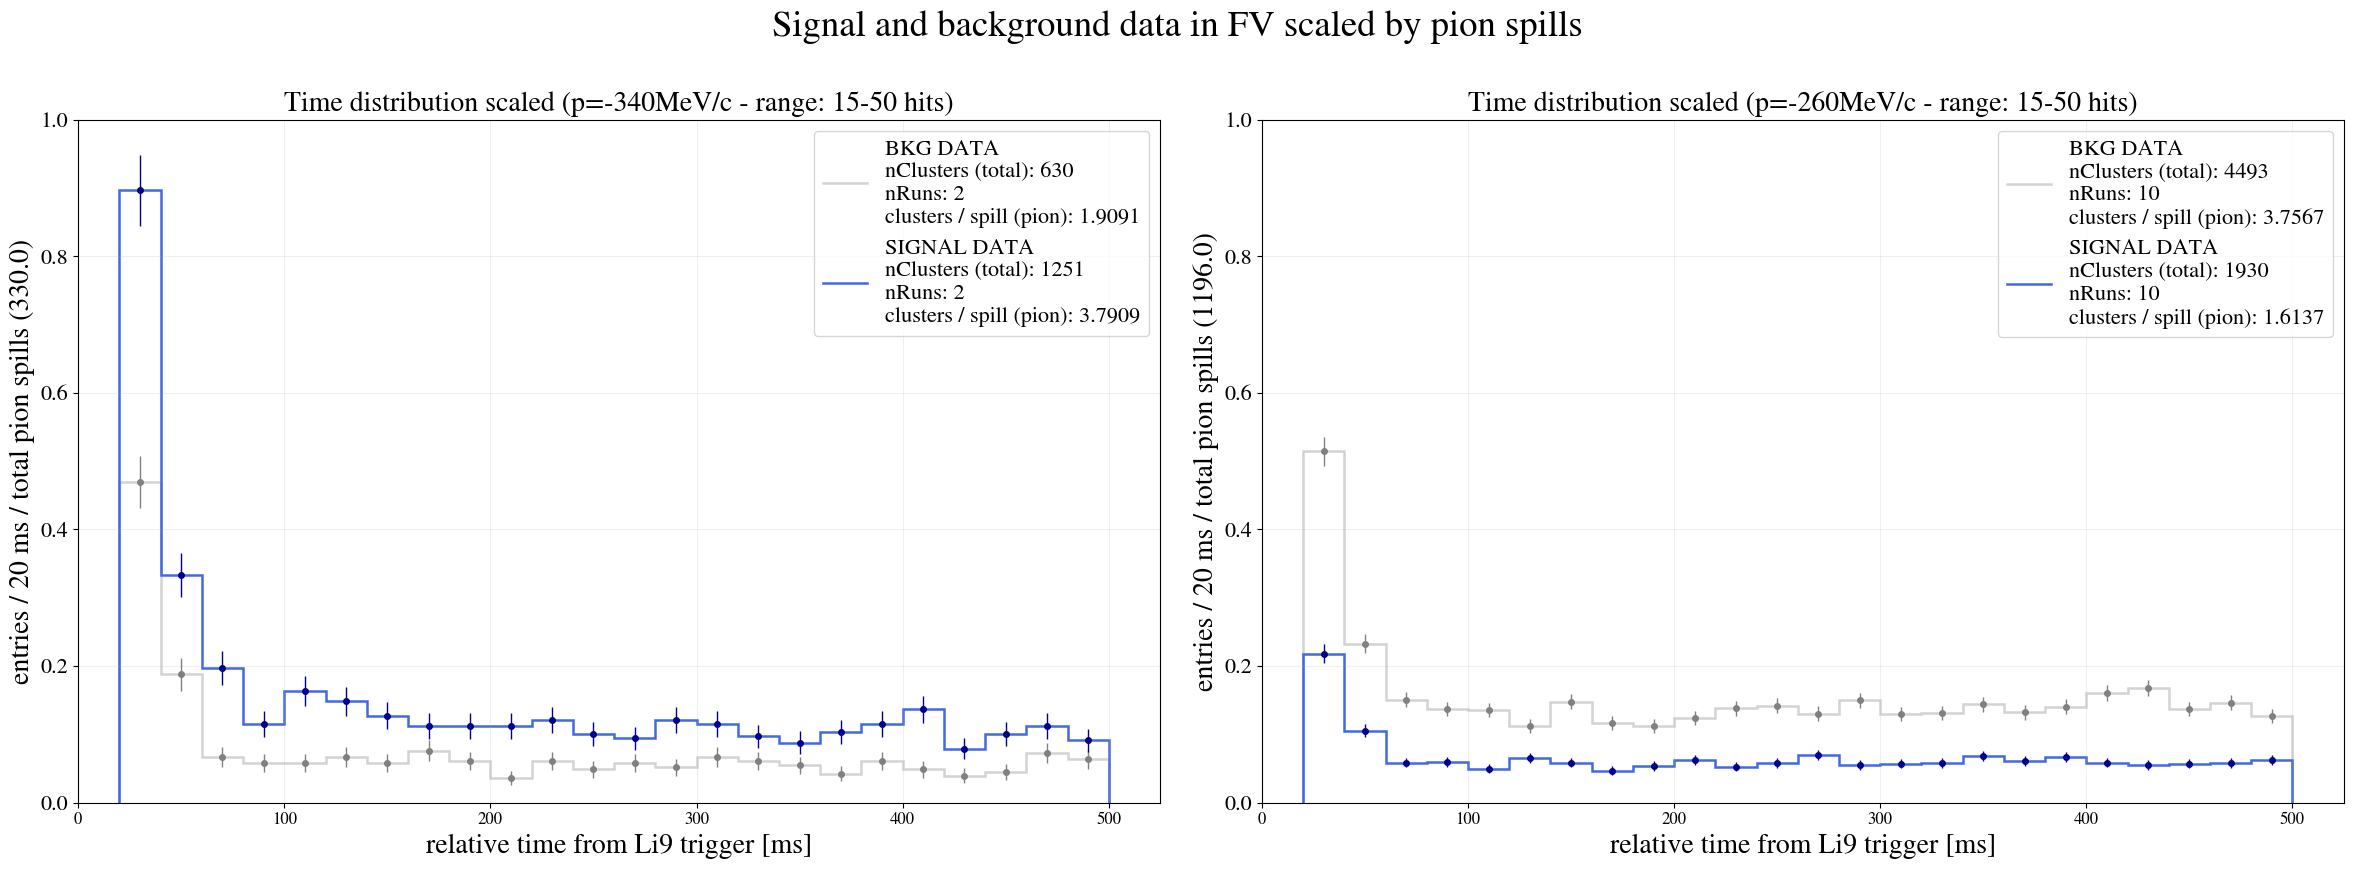

In [103]:
# --- 1. DYNAMIC RETRIEVAL OF PION SPILLS FROM MASTER TABLE ---
master_table_path = "/scratch/elena/9Li/results/isotopes_output/master_table_all_runs.csv"
if not os.path.exists(master_table_path):
    raise FileNotFoundError(f"Master table not found at '{master_table_path}'. Please check the path.")

df_master = pd.read_csv(master_table_path)

# Dynamically sum total pion spills from your master table for each beam momentum configuration
spills_340_pion = df_master[df_master["Beam p (MeV/c)"] == -340]["N spills with pions"].sum()
spills_260_pion = df_master[df_master["Beam p (MeV/c)"] == -260]["N spills with pions"].sum()

print(f"--> [OK] Total pion spills for -340 MeV/c: {spills_340_pion}")
print(f"--> [OK] Total pion spills for -260 MeV/c: {spills_260_pion}")

# --- 2. DATA LOADING & FILTERING ---
dfs_340_sig = []
dfs_340_bkg = []
dfs_260_sig = []
dfs_260_bkg = []

for run in runs:
    run_folder = f"{base_dir }/run{run}/processed"
    
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    # Load signal data
    if os.path.exists(sig_file):
        try:
            df_sig = pd.read_pickle(sig_file)
            if not df_sig.empty:
                df_sig['origin_run'] = run
                if get_beam_momentum(run) == "-340 MeV/c":
                    dfs_340_sig.append(df_sig)
                else:
                    dfs_260_sig.append(df_sig)
        except Exception as e:
            print(f"Error loading signal file {sig_file}: {e}")

    # Load background data
    if os.path.exists(bkg_file):
        try:
            df_bkg = pd.read_pickle(bkg_file)
            if not df_bkg.empty:
                df_bkg['origin_run'] = run
                if get_beam_momentum(run) == "-340 MeV/c":
                    dfs_340_bkg.append(df_bkg)
                else:
                    dfs_260_bkg.append(df_bkg)
        except Exception as e:
            print(f"Error loading background file {bkg_file}: {e}")

# Safe dataframe concatenation
df_340_sig_comb = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_340_bkg_comb = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()
df_260_sig_comb = pd.concat(dfs_260_sig, ignore_index=True) if dfs_260_sig else pd.DataFrame()
df_260_bkg_comb = pd.concat(dfs_260_bkg, ignore_index=True) if dfs_260_bkg else pd.DataFrame()

# --- 3. PLOTTING CONFIGURATION ---
rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

plot_configs = [
    {
        "df_sig": df_340_sig_comb,
        "df_bkg": df_340_bkg_comb,
        "ax": axs[0],
        "title": "Time distribution scaled (p=-340MeV/c - range: 15-50 hits)",
        "num_runs_sig": len(dfs_340_sig),
        "num_runs_bkg": len(dfs_340_bkg),
        "n_spills_pion": spills_340_pion  # <-- Dynamic master table value
    },
    {
        "df_sig": df_260_sig_comb,
        "df_bkg": df_260_bkg_comb,
        "ax": axs[1],
        "title": "Time distribution scaled (p=-260MeV/c - range: 15-50 hits)",
        "num_runs_sig": len(dfs_260_sig),
        "num_runs_bkg": len(dfs_260_bkg),
        "n_spills_pion": spills_260_pion  # <-- Dynamic master table value
    }
]

for config in plot_configs:
    ax = config["ax"]
    ax.set_title(config["title"])
    pion_spills = config["n_spills_pion"]
    
    def plot_sample(df_plot, sample_label, hist_color, marker_color, num_runs):
        if df_plot.empty or (time_column not in df_plot.columns):
            return False
            
        time_in_ms = df_plot[time_column] / 1e6

        counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # --- SCALING APPLIED WITH TOTAL PION SPILLS ---
        counts_scaled = counts / pion_spills
        errors_scaled = np.sqrt(np.maximum(counts, 1)) / pion_spills
        #errors_scaled = np.sqrt(counts) / pion_spills

        label_text = (
            f"{sample_label}\n"
            f"nClusters (total): {len(df_plot)}\n"
            f"nRuns: {num_runs}\n"
            f"clusters / spill (pion): {len(df_plot)/pion_spills:.4f}"
        )

        ax.stairs(counts_scaled, bin_edges, color=hist_color, linewidth=1.8, label=label_text)
        ax.errorbar(bin_centers, counts_scaled, yerr=errors_scaled, fmt="o", color=marker_color, markersize=4, capsize=0, elinewidth=1, ls="none")
        return True

    # Plot background
    has_bkg = plot_sample(
        config["df_bkg"], "BKG DATA", 
        hist_color="lightgray", marker_color="gray", 
        num_runs=config["num_runs_bkg"]
    )

    # Plot signal
    has_sig = plot_sample(
        config["df_sig"], "SIGNAL DATA", 
        hist_color="royalblue", marker_color="darkblue", 
        num_runs=config["num_runs_sig"]
    )

    if not has_sig and not has_bkg:
        ax.text(0.5, 0.5, "No data within FV (signal or BKG)", transform=ax.transAxes, ha="center")
        continue

    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms / total pion spills ({pion_spills})") 
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    
    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    ax.set_ylim(0,1.0)
    ax.legend(loc="upper right", frameon=True)

plt.suptitle("Signal and background data in FV scaled by pion spills")
plt.tight_layout()
plt.show()

--> [OK] Total pion spills for -340 MeV/c: 330.0
--> [OK] Total pion spills for -260 MeV/c: 1196.0


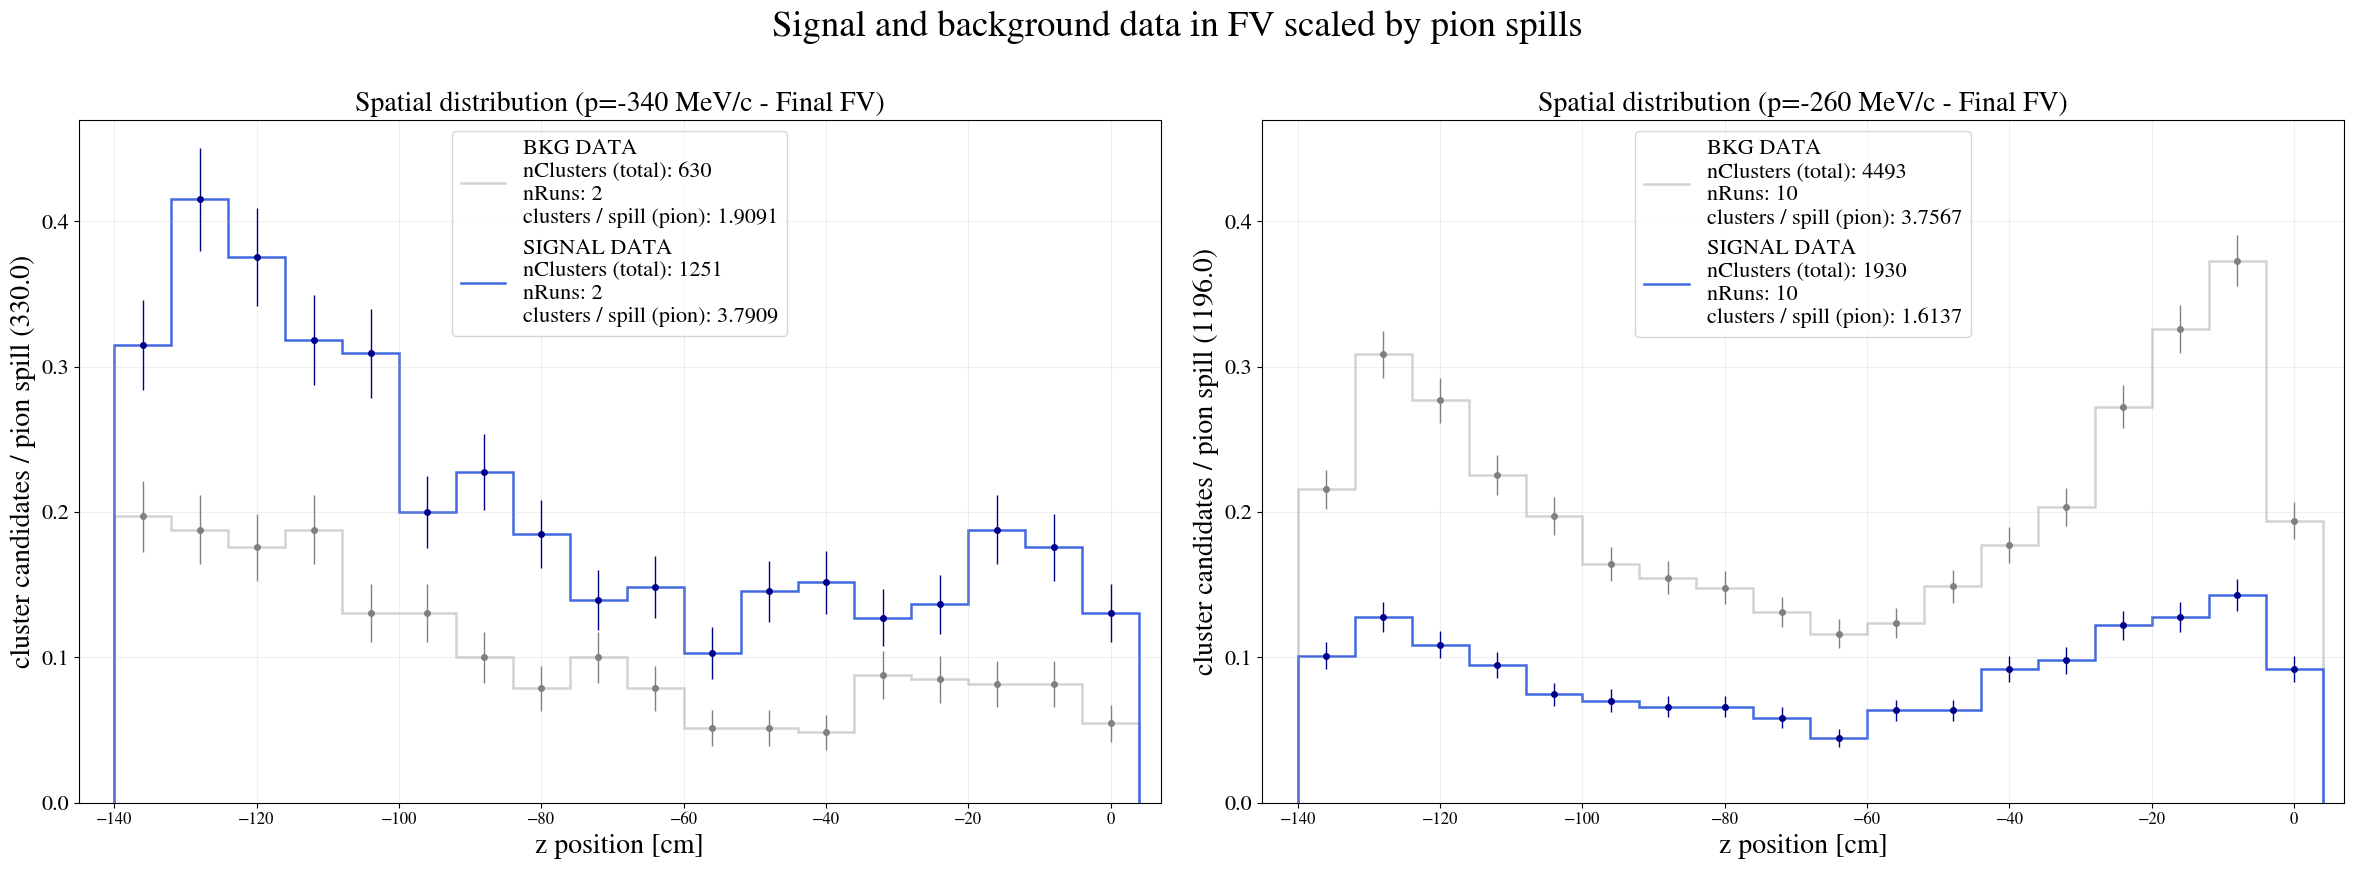

In [121]:
# --- 1. DYNAMIC RETRIEVAL OF PION SPILLS FROM MASTER TABLE ---
master_table_path = "/scratch/elena/9Li/results/isotopes_output/master_table_all_runs.csv"

if not os.path.exists(master_table_path):
    raise FileNotFoundError(
        f"Master table not found at '{master_table_path}'. Please check the path."
    )

df_master = pd.read_csv(master_table_path)

# Dynamically sum total pion spills from your master table for each beam momentum configuration
spills_340_pion = df_master[
    df_master["Beam p (MeV/c)"] == -340
]["N spills with pions"].sum()

spills_260_pion = df_master[
    df_master["Beam p (MeV/c)"] == -260
]["N spills with pions"].sum()

print(f"--> [OK] Total pion spills for -340 MeV/c: {spills_340_pion}")
print(f"--> [OK] Total pion spills for -260 MeV/c: {spills_260_pion}")


# --- 2. DATA LOADING & FILTERING ---
dfs_340_sig = []
dfs_340_bkg = []
dfs_260_sig = []
dfs_260_bkg = []

for run in runs:

    run_folder = f"{base_dir}/run{run}/processed"

    sig_file = os.path.join(
        run_folder,
        f"Final_FV_Li9_clusters_run{run}.pkl"
    )

    bkg_file = os.path.join(
        run_folder,
        f"Final_FV_Li9_clusters_run{run}_BKG.pkl"
    )

    # ---------------- Signal ----------------

    if os.path.exists(sig_file):

        try:

            df_sig = pd.read_pickle(sig_file)

            if not df_sig.empty:

                df_sig["origin_run"] = run

                if get_beam_momentum(run) == "-340 MeV/c":
                    dfs_340_sig.append(df_sig)
                else:
                    dfs_260_sig.append(df_sig)

        except Exception as e:

            print(f"Error loading signal file {sig_file}: {e}")

    # ---------------- Background ----------------

    if os.path.exists(bkg_file):

        try:

            df_bkg = pd.read_pickle(bkg_file)

            if not df_bkg.empty:

                df_bkg["origin_run"] = run

                if get_beam_momentum(run) == "-340 MeV/c":
                    dfs_340_bkg.append(df_bkg)
                else:
                    dfs_260_bkg.append(df_bkg)

        except Exception as e:

            print(f"Error loading background file {bkg_file}: {e}")


# Safe dataframe concatenation

df_340_sig_comb = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_340_bkg_comb = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()

df_260_sig_comb = pd.concat(dfs_260_sig, ignore_index=True) if dfs_260_sig else pd.DataFrame()
df_260_bkg_comb = pd.concat(dfs_260_bkg, ignore_index=True) if dfs_260_bkg else pd.DataFrame()


# --- 3. PLOTTING CONFIGURATION ---

rcParams["figure.figsize"] = [24,9]

fig, axs = plt.subplots(1,2,sharey=False)

bins_z = np.arange(-140, 10, 8)
z_column = "v_z_fine"

plot_configs = [

    {
        "df_sig": df_340_sig_comb,
        "df_bkg": df_340_bkg_comb,
        "ax": axs[0],
        "title": "Spatial distribution (p=-340 MeV/c - Final FV)",
        "num_runs_sig": len(dfs_340_sig),
        "num_runs_bkg": len(dfs_340_bkg),
        "n_spills_pion": spills_340_pion,
    },

    {
        "df_sig": df_260_sig_comb,
        "df_bkg": df_260_bkg_comb,
        "ax": axs[1],
        "title": "Spatial distribution (p=-260 MeV/c - Final FV)",
        "num_runs_sig": len(dfs_260_sig),
        "num_runs_bkg": len(dfs_260_bkg),
        "n_spills_pion": spills_260_pion,
    }

]


for config in plot_configs:

    ax = config["ax"]
    ax.set_title(config["title"])

    pion_spills = config["n_spills_pion"]


    def plot_sample(df_plot, sample_label, hist_color, marker_color, num_runs):

        if df_plot.empty or (z_column not in df_plot.columns):
            return False

        counts, bin_edges = np.histogram(
            df_plot[z_column],
            bins=bins_z
        )

        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        counts_scaled = counts / pion_spills
        errors_scaled = np.sqrt(np.maximum(counts,1)) / pion_spills

        label_text = (
            f"{sample_label}\n"
            f"nClusters (total): {len(df_plot)}\n"
            f"nRuns: {num_runs}\n"
            f"clusters / spill (pion): {len(df_plot)/pion_spills:.4f}"
        )

        ax.stairs(
            counts_scaled,
            bin_edges,
            color=hist_color,
            linewidth=1.8,
            label=label_text
        )

        ax.errorbar(
            bin_centers,
            counts_scaled,
            yerr=errors_scaled,
            fmt="o",
            color=marker_color,
            markersize=4,
            capsize=0,
            elinewidth=1,
            ls="none"
        )

        return True


    # Plot background

    has_bkg = plot_sample(
        config["df_bkg"],
        "BKG DATA",
        hist_color="lightgray",
        marker_color="gray",
        num_runs=config["num_runs_bkg"]
    )


    # Plot signal

    has_sig = plot_sample(
        config["df_sig"],
        "SIGNAL DATA",
        hist_color="royalblue",
        marker_color="darkblue",
        num_runs=config["num_runs_sig"]
    )


    if not has_sig and not has_bkg:

        ax.text(
            0.5,
            0.5,
            "No data within FV (signal or BKG)",
            transform=ax.transAxes,
            ha="center"
        )

        continue


    ax.set_xlabel("z position [cm]")

    ax.set_ylabel(
        f"cluster candidates / pion spill ({pion_spills})"
    )

    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    ax.set_ylim(0, 0.47)
    ax.set_xlim(-145, 7)
    ax.legend(loc="upper center", frameon=True)


plt.suptitle("Signal and background data in FV scaled by pion spills")

plt.tight_layout()

plt.show()

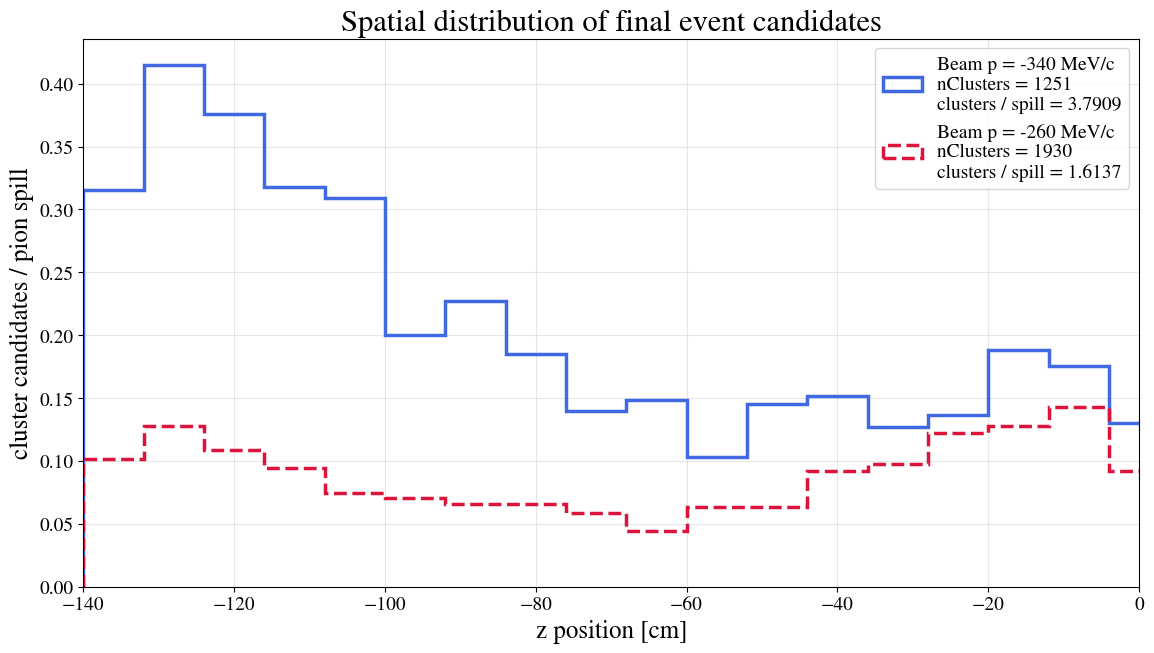

In [122]:
bins_z = np.arange(-140, 10, 8)

weights340 = np.ones(len(df_340_sig_comb)) / spills_340_pion
weights260 = np.ones(len(df_260_sig_comb)) / spills_260_pion

plt.figure(figsize=(12,7))

plt.hist(
    df_340_sig_comb["v_z_fine"],
    bins=bins_z,
    weights=weights340,
    histtype="step",
    linewidth=2.5,
    color="royalblue",
    label=(
        f"Beam p = -340 MeV/c\n"
        f"nClusters = {len(df_340_sig_comb)}\n"
        f"clusters / spill = {len(df_340_sig_comb)/spills_340_pion:.4f}"
    )
)

plt.hist(
    df_260_sig_comb["v_z_fine"],
    bins=bins_z,
    weights=weights260,
    histtype="step",
    linestyle = "--",
    linewidth=2.5,
    color="crimson",
    label=(
        f"Beam p = -260 MeV/c\n"
        f"nClusters = {len(df_260_sig_comb)}\n"
        f"clusters / spill = {len(df_260_sig_comb)/spills_260_pion:.4f}"
    )
)

plt.xlabel("z position [cm]", fontsize=18)
plt.ylabel("cluster candidates / pion spill", fontsize=18)

plt.title(r"Spatial distribution of final event candidates", fontsize=22)

plt.xlim(-140, 0)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)

plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

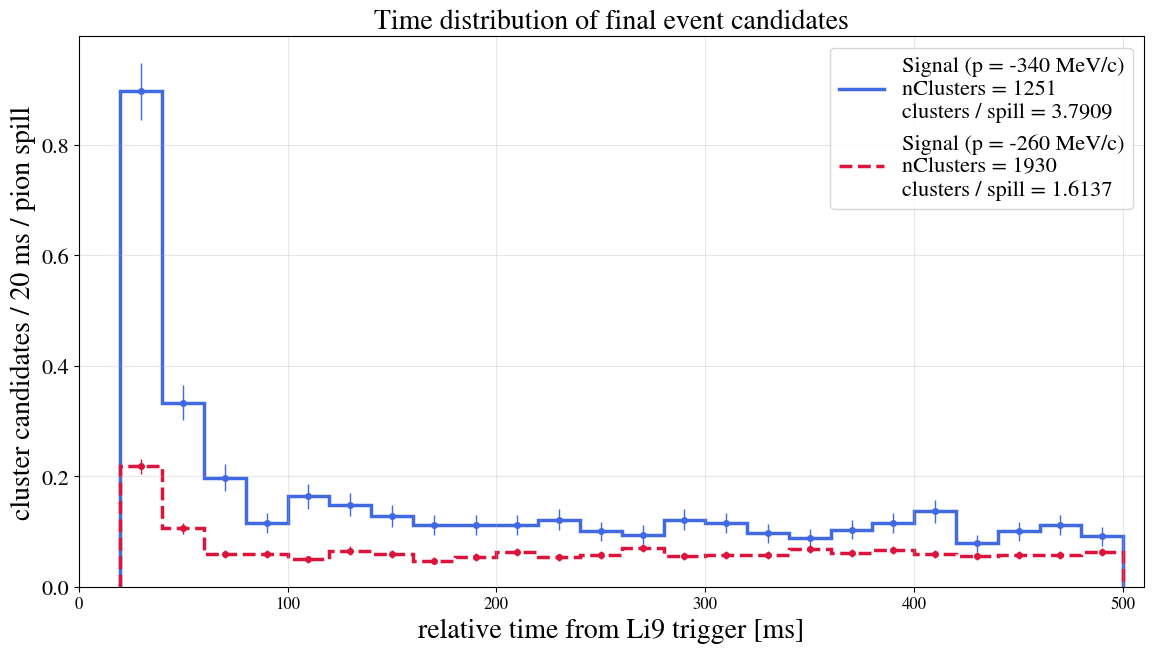

In [143]:
# ------------------------------------------------------------
# Time distribution (Signal + Background)
# ------------------------------------------------------------

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)

time_column = "t_window_start_rel_ns"

plt.figure(figsize=(12,7))


def plot_sample(df, pion_spills, color, linestyle, label):

    if df.empty:
        return

    # Convert ns -> ms
    time_ms = df[time_column] / 1e6

    # Recover the true time (20-500 ms)
    counts, edges = np.histogram(time_ms + 20, bins=bins)

    centers = 0.5 * (edges[:-1] + edges[1:])

    counts_scaled = counts / pion_spills
    errors_scaled = np.sqrt(np.maximum(counts, 1)) / pion_spills

    plt.stairs(
        counts_scaled,
        edges,
        color=color,
        linestyle=linestyle,
        linewidth=2.5,
        label=(
            f"{label}\n"
            f"nClusters = {len(df)}\n"
            f"clusters / spill = {len(df)/pion_spills:.4f}"
        )
    )

    plt.errorbar(
        centers,
        counts_scaled,
        yerr=errors_scaled,
        fmt="o",
        color=color,
        markersize=4,
        capsize=0,
        elinewidth=1,
        ls="none"
    )


plot_sample(df_340_sig_comb, spills_340_pion, color="royalblue", linestyle="-", label="Signal (p = -340 MeV/c)")
plot_sample(df_260_sig_comb, spills_260_pion, color="crimson", linestyle="--", label="Signal (p = -260 MeV/c)")

plt.xlabel("relative time from Li9 trigger [ms]")
plt.ylabel("cluster candidates / 20 ms / pion spill")
plt.title("Time distribution of final event candidates")

plt.xlim(0, 510)
plt.xticks()
plt.yticks()
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

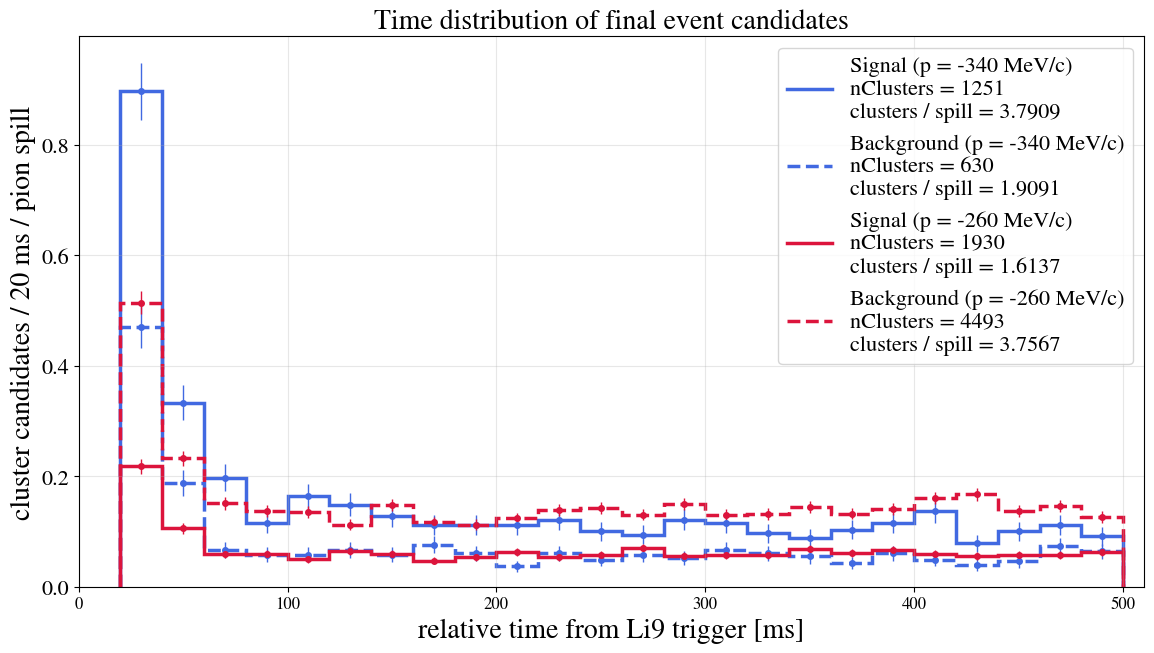

In [141]:
# ------------------------------------------------------------
# Plot all four samples
# ------------------------------------------------------------
plt.figure(figsize=(12,7))

plot_sample(df_340_sig_comb, spills_340_pion, color="royalblue", linestyle="-", label="Signal (p = -340 MeV/c)")
plot_sample(df_340_bkg_comb, spills_340_pion, color="royalblue", linestyle="--", label="Background (p = -340 MeV/c)")
plot_sample(df_260_sig_comb, spills_260_pion, color="crimson", linestyle="-", label="Signal (p = -260 MeV/c)")
plot_sample(df_260_bkg_comb, spills_260_pion, color="crimson", linestyle="--", label="Background (p = -260 MeV/c)")

plt.xlabel("relative time from Li9 trigger [ms]")
plt.ylabel("cluster candidates / 20 ms / pion spill")
plt.title("Time distribution of final event candidates")

plt.xlim(0, 510)
plt.xticks()
plt.yticks()
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()